# flow-first vs the thesis primal on Benders-harvested instances

Both variants trained on `data/ED_data_gen/harvested_training_data_perturb_mix.pkl`:
48 000 deduped ED states whose capacities are the investments **exact Benders actually
visited** on 81 perturbed 3-node GEP instances (`gen_GEP/`), rather than draws from the
node-budget capacity sampler that produced every dataset behind F1-F32.

This is the IDEAS **I9** question: *the master will query capacities the sampler never drew.*

Run from the repo root with the project venv:
```
.venv/bin/python -m flowfirst.train --variant flowfirst       --config flowfirst/configs/config-3node-harvest.json --epochs 250 --tag harvest
.venv/bin/python -m flowfirst.train --variant old-prioritized --config flowfirst/configs/config-3node-harvest.json --epochs 250 --tag harvest
```

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

REPO = Path.cwd() if (Path.cwd() / "flowfirst").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO))
torch.set_default_dtype(torch.float64)

from flowfirst.dual import PathPolish, Polish, load_run
from flowfirst.train import line_bounds

RUNS = REPO / "flowfirst" / "runs"

# the two runs this notebook is about, plus the sampler-trained pair for reference
HARVEST = {"flow-first": "flowfirst-harvest", "thesis primal": "old-prioritized-harvest"}
SAMPLER = {"flow-first": "flowfirst-3", "thesis primal": "old-prioritized"}

COLOR = {"flow-first": "#0072B2", "thesis primal": "#D55E00"}


def metrics(run):
    return pd.read_csv(RUNS / run / "metrics.csv")


def run_args(run):
    return json.load(open(RUNS / run / "args.json"))


for label, run in {**HARVEST, **SAMPLER}.items():
    a = run_args(run)
    print(f"{run:26} {label:14} {a['epochs']:>4} epochs  {a['n_train']:>6} train / {a['n_valid']:>5} valid  "
          f"{a['n_params']:>7} params  config {Path(a['config']).name}")

flowfirst-3                flow-first      250 epochs   26214 train /  3276 valid    67053 params  config config-3node.json
old-prioritized            thesis primal   250 epochs   26214 train /  3276 valid    68571 params  config config-3node.json


## 1. What the harvested set looks like

The distribution is the whole point of the experiment, so look at it before the models.

In [2]:
from flowfirst.dataset import load_or_create

data, cfg = load_or_create(str(REPO / "flowfirst/configs/config-3node-harvest.json"))
N, G = data.num_n, data.num_g
X = data.X
D, cap = X[:, :N], X[:, N:N + G]
y = data.opt_targets["y_operational"]
p_star, f_star, md_star = data.split_dec_vars_from_Y(y)
f_lb, f_ub = line_bounds(data)

shortage = md_star.sum(1) > 1e-6
sat = (f_star <= f_lb + 1e-6) | (f_star >= f_ub - 1e-6)

print(f"instances {X.shape[0]},  nodes {N},  generators {G},  lines {data.num_l},  VOLL {data.pVOLL}")
print(f"shortage share                 {shortage.double().mean():.3f}")
print(f"at least one saturated line    {sat.any(1).double().mean():.3f}")
print("generators and cost: " + ", ".join(f"{g[0]}-{g[1]} {c:g}" for g, c in zip(data.G, data.cost_vec.tolist())))
print("\ncost ties (F19: harmless for flow-first, but they make the optimum a face, not a point):")
costs = data.cost_vec.tolist()
for c in sorted(set(costs)):
    tied = [f"{g[0]}-{g[1]}" for g, cc in zip(data.G, costs) if cc == c]
    if len(tied) > 1:
        print(f"  {c:g}: {', '.join(tied)}")

instances 48000,  nodes 3,  generators 6,  lines 3,  VOLL 10.0
shortage share                 0.234
at least one saturated line    1.000
generators and cost: BEL-WindOff 0.005, BEL-Gas 0.05, GER-Gas 0.05, GER-SunPV 0.0001, FRA-Nuclear 0.01, FRA-SunPV 0.0001

cost ties (F19: harmless for flow-first, but they make the optimum a face, not a point):
  0.0001: GER-SunPV, FRA-SunPV
  0.05: BEL-Gas, GER-Gas


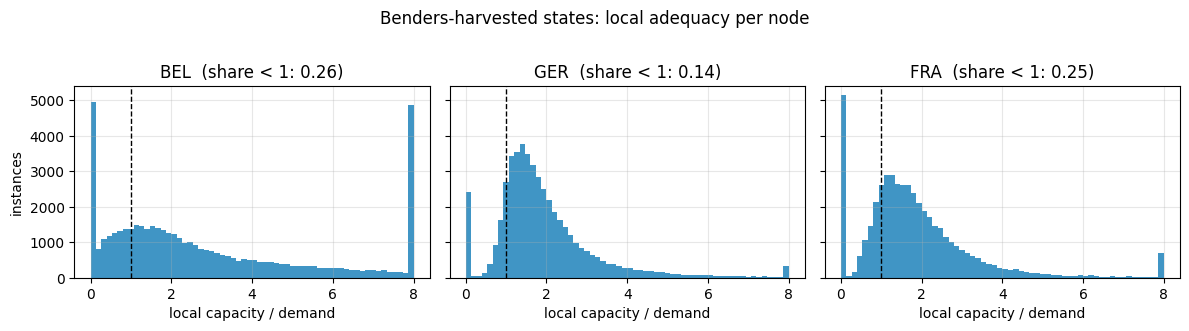

states with a node at zero local capacity: 0.137


In [3]:
# capacity / demand per node: how much of the box the harvest actually visits
node_cap = cap @ data.node_to_gen_mask.T
ratio = node_cap / D

fig, axes = plt.subplots(1, N, figsize=(4 * N, 3.2), sharey=True)
for i, ax in enumerate(axes):
    ax.hist(ratio[:, i].clamp(max=8).numpy(), bins=60, color="#0072B2", alpha=0.75)
    ax.axvline(1.0, color="black", lw=1, ls="--")
    ax.set_title(f"{data.N[i]}  (share < 1: {(ratio[:, i] < 1).double().mean():.2f})")
    ax.set_xlabel("local capacity / demand")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("instances")
fig.suptitle("Benders-harvested states: local adequacy per node", y=1.02)
plt.tight_layout()
plt.show()

# a spike at zero capacity would be the Benders signature: the master starts at u = 0 and
# walks up, so early-iteration states are capacity-starved in a way the sampler never draws
print(f"states with a node at zero local capacity: {(node_cap.min(1).values < 1e-9).double().mean():.3f}")

## 2. Training curves

`gap_total` is the ratio of summed objectives (the honest metric, F5); `gap_mean` is the
mean per-instance relative gap, which a few near-zero-objective instances can dominate.

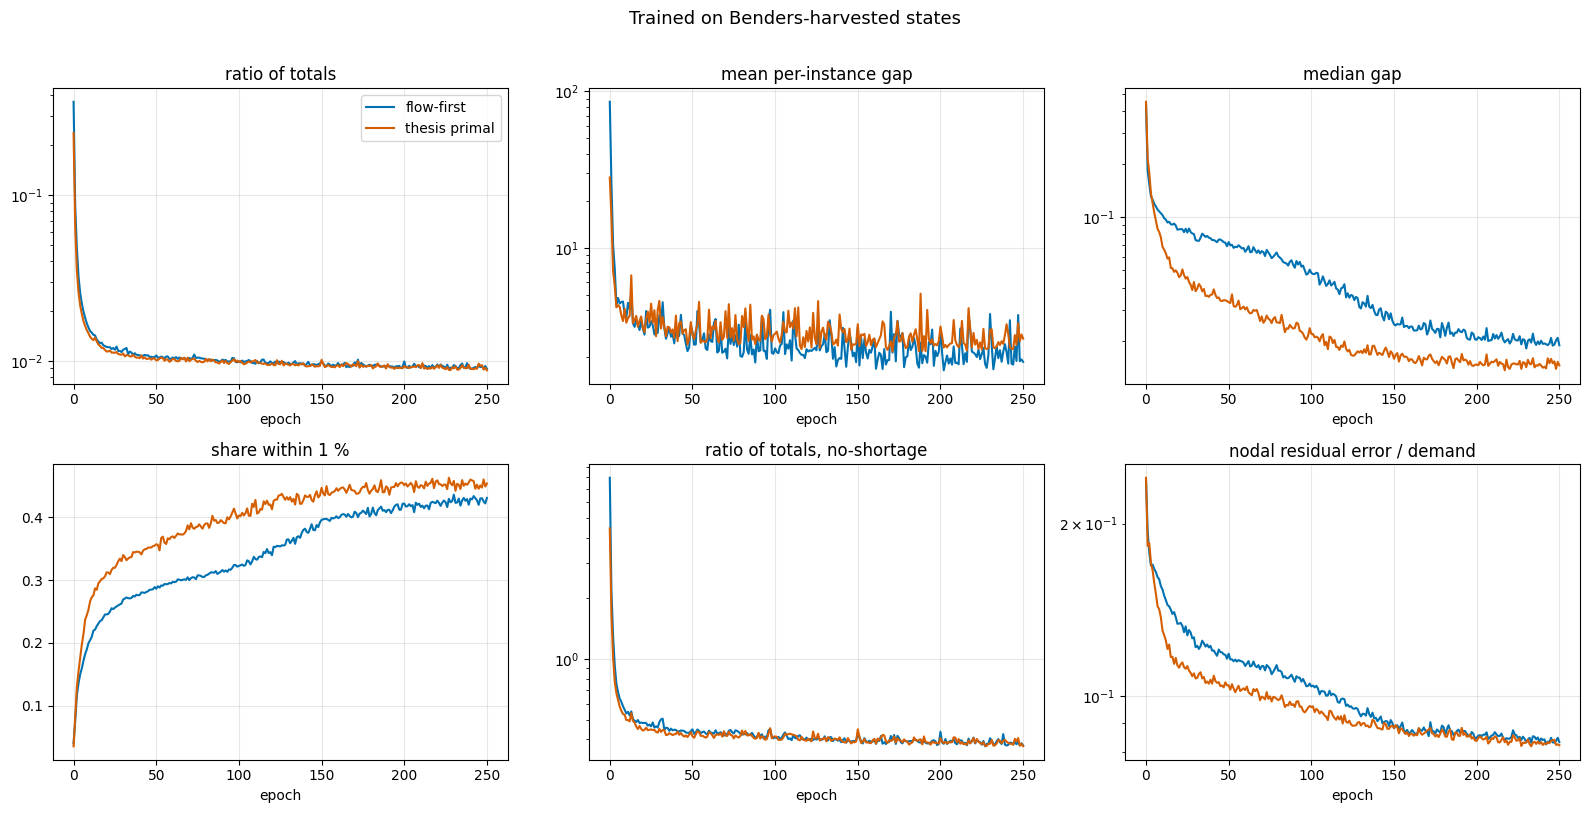

In [4]:
PANELS = [
    ("val/gap_total", "ratio of totals", True),
    ("val/gap_mean", "mean per-instance gap", True),
    ("val/gap_median", "median gap", True),
    ("val/within_1pct", "share within 1 %", False),
    ("val/gap_total_noshortage", "ratio of totals, no-shortage", True),
    ("val/residual_err_rel", "nodal residual error / demand", True),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (col, title, logy) in zip(axes.ravel(), PANELS):
    for label, run in HARVEST.items():
        m = metrics(run).dropna(subset=[col])
        ax.plot(m["epoch"], m[col], color=COLOR[label], label=label, lw=1.5)
    if logy:
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
axes[0, 0].legend()
fig.suptitle("Trained on Benders-harvested states", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# generalization: training-set fit against validation, same metric
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col in zip(axes, ["gap_total", "gap_total_noshortage"]):
    for label, run in HARVEST.items():
        m = metrics(run).dropna(subset=[f"val/{col}"])
        ax.plot(m["epoch"], m[f"trainset/{col}"], color=COLOR[label], ls="--", lw=1.2, label=f"{label} train")
        ax.plot(m["epoch"], m[f"val/{col}"], color=COLOR[label], lw=1.6, label=f"{label} valid")
    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Final metrics side by side

In [5]:
COLS = ["val/gap_total", "val/gap_total_noshortage", "val/gap_mean", "val/gap_median",
        "val/within_1pct", "val/gap_dispatch_part", "val/gap_voll_part",
        "val/residual_err_rel", "val/price_acc", "val/line_sat_acc"]

rows = {}
for group, runs in (("harvest", HARVEST), ("sampler", SAMPLER)):
    for label, run in runs.items():
        m = metrics(run).dropna(subset=["val/gap_total"])
        rows[f"{label} / {group}"] = m.iloc[-1][COLS]

final = pd.DataFrame(rows).T
final.columns = [c.replace("val/", "") for c in final.columns]
final.style.format("{:.4f}")

,gap_total,gap_total_noshortage,gap_mean,gap_median,within_1pct,gap_dispatch_part,gap_voll_part,residual_err_rel,price_acc,line_sat_acc
flow-first / harvest,0.0090,0.3721,1.8619,0.0188,0.4308,0.4802,1.3817,0.0833,0.8594,0.5899
thesis primal / harvest,0.0088,0.3691,2.6244,0.0145,0.4538,0.3540,2.2704,0.0823,0.8596,0.5650
flow-first / sampler,0.0058,0.1223,0.0914,0.0010,0.7277,0.0153,0.0761,0.0437,0.7953,0.7630
thesis primal / sampler,0.0059,0.1239,0.0921,0.0011,0.7204,0.0162,0.0759,0.0454,0.7950,0.7651


> **Read the two groups separately.** The sampler runs are on `config-3node.json`, whose
> system is BEL WindOff/Gas, GER **SunPV/Lignite**, FRA **Nuclear/Oil** with six distinct
> costs. The harvest is a *different* system: GER **Gas/SunPV**, FRA **Nuclear/SunPV**, with
> two cost ties. Harvest-vs-sampler numbers are therefore not a controlled comparison —
> see section 7 for what would make one.

## 4. Per-instance gaps on the validation split

The curves above are aggregates. Here the models are re-evaluated instance by instance,
on exactly the split `train.py` used (80 / 10 / 10, validation is the middle tenth).

In [6]:
def evaluate_run(run, which="valid"):
    """Per-instance gap, its parts, and the raw flows, on train.py's own split."""
    data, net, _ = load_run(str(RUNS / run))
    n = data.X.shape[0]
    n_train, n_valid = int(0.8 * n), int(0.1 * n)
    idx = (torch.arange(0, n_train) if which == "train"
           else torch.arange(n_train, n_train + n_valid))
    X = data.X[idx]
    ref_obj = data.opt_targets["obj"][idx]
    ref_y = data.opt_targets["y_operational"][idx]
    ref_p, ref_f, ref_md = data.split_dec_vars_from_Y(ref_y)
    with torch.no_grad():
        y, _, f = net(X)
    p, _, md = data.split_dec_vars_from_Y(y)
    obj = data.obj_fn(X, y)
    return dict(
        data=data, net=net, X=X, f=f, obj=obj, ref_obj=ref_obj,
        gap=(obj - ref_obj) / ref_obj,
        gap_dispatch=((p.abs() @ data.cost_vec) - (ref_p @ data.cost_vec)) / ref_obj,
        gap_voll=data.pVOLL * (md.abs().sum(1) - ref_md.sum(1)) / ref_obj,
        shortage=ref_md.sum(1) > 1e-6,
    )


ev = {label: evaluate_run(run) for label, run in HARVEST.items()}
for label, e in ev.items():
    g = e["gap"]
    print(f"{label:14} n={len(g):>5}  total {(e['obj'].sum() - e['ref_obj'].sum()) / e['ref_obj'].sum():.5f}  "
          f"mean {g.mean():.4f}  median {g.median():.5f}  p90 {g.quantile(0.90):.4f}  "
          f"p99 {g.quantile(0.99):.3f}  max {g.max():.2f}  within1% {(g < 0.01).double().mean():.3f}")

flow-first     n= 4800  total 0.00895  mean 1.8619  median 0.01883  p90 1.1596  p99 25.402  max 1558.09  within1% 0.431
thesis primal  n= 4800  total 0.00877  mean 2.6244  median 0.01449  p90 1.0996  p99 21.608  max 2108.09  within1% 0.454


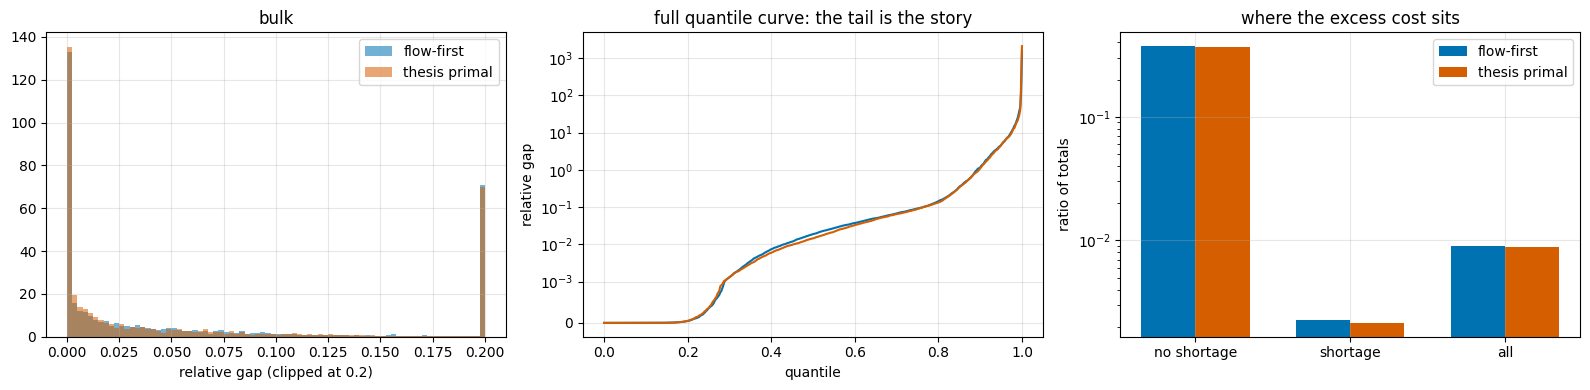

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) the bulk of the distribution
for label, e in ev.items():
    axes[0].hist(e["gap"].clamp(max=0.2).numpy(), bins=80, alpha=0.55,
                 color=COLOR[label], label=label, density=True)
axes[0].set_xlabel("relative gap (clipped at 0.2)")
axes[0].set_title("bulk")
axes[0].legend()

# (b) the tail, which the mean is made of
for label, e in ev.items():
    q = torch.linspace(0, 1, 501)
    axes[1].plot(q.numpy(), e["gap"].quantile(q).numpy(), color=COLOR[label], label=label)
axes[1].set_yscale("symlog", linthresh=1e-3)
axes[1].set_xlabel("quantile")
axes[1].set_ylabel("relative gap")
axes[1].set_title("full quantile curve: the tail is the story")
axes[1].grid(alpha=0.3)

# (c) shortage vs no-shortage, ratio of totals
labels, width = list(ev), 0.35
for k, label in enumerate(labels):
    e = ev[label]
    s = e["shortage"]
    vals = [((e["obj"][m].sum() - e["ref_obj"][m].sum()) / e["ref_obj"][m].sum()).item()
            for m in (~s, s, torch.ones_like(s))]
    axes[2].bar([i + k * width for i in range(3)], vals, width, color=COLOR[label], label=label)
axes[2].set_xticks([i + width / 2 for i in range(3)])
axes[2].set_xticklabels(["no shortage", "shortage", "all"])
axes[2].set_ylabel("ratio of totals")
axes[2].set_yscale("log")
axes[2].set_title("where the excess cost sits")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# is the excess lost load, or dispatching the wrong units? (F17: the thesis primal's
# stall was its production head, i.e. a large dispatch part given its own flows)
split = pd.DataFrame({
    label: {
        "gap mean": e["gap"].mean().item(),
        "dispatch part": e["gap_dispatch"].mean().item(),
        "VOLL part": e["gap_voll"].mean().item(),
        "dispatch part, no-shortage": e["gap_dispatch"][~e["shortage"]].mean().item(),
        "VOLL part, no-shortage": e["gap_voll"][~e["shortage"]].mean().item(),
    } for label, e in ev.items()
}).T
split.style.format("{:.5f}")

,gap mean,dispatch part,VOLL part,"dispatch part, no-shortage","VOLL part, no-shortage"
flow-first,1.86192,0.48021,1.38172,0.62768,1.78195
thesis primal,2.62440,0.35396,2.27044,0.46266,2.94476


## 5. Head to head, instance by instance

Both models see the same validation instances in the same order, so they pair up.

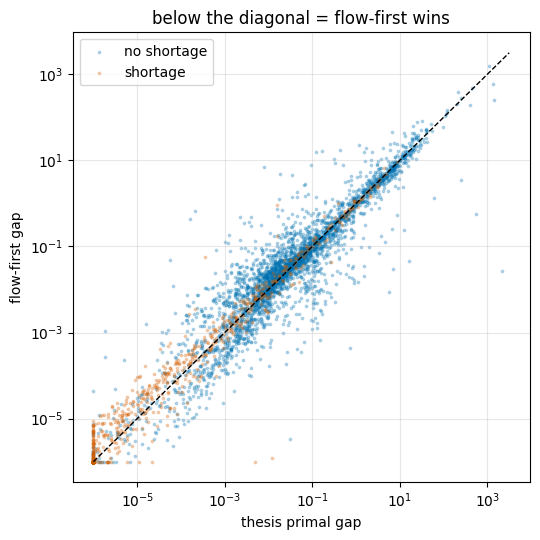

flow-first strictly better on 0.424 of instances
  among no-shortage: 0.463   among shortage: 0.298


In [9]:
a, b = ev["flow-first"]["gap"], ev["thesis primal"]["gap"]
sh = ev["flow-first"]["shortage"]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
lo, hi = 1e-6, float(max(a.max(), b.max())) * 1.5
ax.scatter(b[~sh].clamp(min=lo), a[~sh].clamp(min=lo), s=3, alpha=0.25, color="#0072B2", label="no shortage")
ax.scatter(b[sh].clamp(min=lo), a[sh].clamp(min=lo), s=3, alpha=0.25, color="#D55E00", label="shortage")
ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("thesis primal gap")
ax.set_ylabel("flow-first gap")
ax.set_title("below the diagonal = flow-first wins")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"flow-first strictly better on {(a < b).double().mean():.3f} of instances")
print(f"  among no-shortage: {(a < b)[~sh].double().mean():.3f}   among shortage: {(a < b)[sh].double().mean():.3f}")

## 6. What the polish does here (F27 / F32 on harvested states)

One sweep of exact per-line line search on the predicted flows, then the exact min-cost
flow. F32 found the sweep divides every 6-node network's gap by 8 to 15 and preserves the
ranking. This checks whether that still holds on the Benders distribution — the thing that
matters, because in the Benders loop the polish is what you would actually deploy.

`PathPolish` is the expensive cell in this notebook (a Python loop over augmentations);
cut the split down with `X[:2000]` if it drags.

In [10]:
rows = []
for label, e in ev.items():
    data_e, X_e, f, ref_obj = e["data"], e["X"], e["f"], e["ref_obj"]
    polish, path = Polish(data_e), PathPolish(data_e)
    _, cost1 = polish(X_e, f, sweeps=1)
    _, cost3 = polish(X_e, f, sweeps=3)
    _, cost_exact, n_aug = path(X_e, f)
    _, _, n_aug_cold = path(X_e, torch.zeros_like(f))
    g0, g1, g3, ge = [(c - ref_obj) / ref_obj for c in (e["obj"], cost1, cost3, cost_exact)]
    rows.append({
        "model": label,
        "raw mean": g0.mean().item(),
        "raw total": ((e["obj"].sum() - ref_obj.sum()) / ref_obj.sum()).item(),
        "1 sweep mean": g1.mean().item(),
        "3 sweeps mean": g3.mean().item(),
        "exact mean": ge.mean().item(),
        "raw within 1%": (g0 < 0.01).double().mean().item(),
        "1 sweep within 1%": (g1 < 0.01).double().mean().item(),
        "augmentations (warm)": n_aug.double().mean().item(),
        "augmentations (cold)": n_aug_cold.double().mean().item(),
    })

pd.DataFrame(rows).set_index("model").style.format("{:.5f}")

,raw mean,raw total,1 sweep mean,3 sweeps mean,exact mean,raw within 1%,1 sweep within 1%,augmentations (warm),augmentations (cold)
model,,,,,,,,,
flow-first,1.86192,0.00895,0.02496,0.01209,0.00000,0.43083,0.89708,2.24063,2.81208
thesis primal,2.62440,0.00877,0.03740,0.00676,0.00000,0.45375,0.93667,2.18000,2.81208


In [11]:
# the certificate: a valid bound per instance from one forward pass, no labels used.
# `bound valid` must be 1.0 — if it is not, the dual recovery is wrong on this distribution.
from flowfirst.dual import PrimalDual

for label, e in ev.items():
    solver = PrimalDual(e["data"], e["net"], polish_sweeps=1, exact=False)
    sol = solver(e["X"])
    true_gap = (sol.primal - e["ref_obj"]) / e["ref_obj"]
    print(f"{label:14} certified gap: mean {sol.certificate.mean():.5f}  median {sol.certificate.median():.5f}  "
          f"within 1% {(sol.certificate < 0.01).double().mean():.3f}   |   "
          f"true gap mean {true_gap.mean():.5f}  bound valid on {(sol.certificate >= true_gap - 1e-9).double().mean():.4f}")

flow-first     certified gap: mean inf  median 0.00000  within 1% 0.896   |   true gap mean 0.02496  bound valid on 1.0000
thesis primal  certified gap: mean 0.04610  median 0.00000  within 1% 0.936   |   true gap mean 0.03740  bound valid on 1.0000


## 7. What this does and does not establish

**Does.** How the two architectures compare *on the distribution Benders actually produces*,
including the capacity-starved early-iteration states the node-budget sampler never draws.

**Does not.** Whether harvest-training beats sampler-training *for Benders deployment*. That
needs the 2x2 — train on each, evaluate on both — and it is not runnable today because the
harvest and the existing `config-3node.json` are different 3-node systems (different
generators, different costs), so a model from one cannot be evaluated on the other.

To make the 2x2 real, build a sampler dataset **on the harvest's own system**: copy
`config-3node-harvest.json` to `config-3node-harvest-sampler.json`, set
`ED_args.use_direct_data` to `false`, give it a fresh `specific_name`, then label it with
Gurobi and train the same two variants on it:

```
export GRB_LICENSE_FILE=.venv/lib/python3.12/site-packages/gurobipy/.libs/gurobi.lic
.venv/bin/python -m flowfirst.dataset flowfirst/configs/config-3node-harvest-sampler.json
.venv/bin/python -m flowfirst.train --variant flowfirst       --config flowfirst/configs/config-3node-harvest-sampler.json --epochs 250 --tag harvest-sampler
.venv/bin/python -m flowfirst.train --variant old-prioritized --config flowfirst/configs/config-3node-harvest-sampler.json --epochs 250 --tag harvest-sampler
```

Then the cell below works. The number that matters is **sampler-trained, harvest-evaluated** —
that is the distribution-shift penalty the Benders master would actually pay.

In [12]:
def cross_evaluate(run, config):
    """Score a trained run on another dataset's validation split. Same system required."""
    data_t, net, _ = load_run(str(RUNS / run))
    data_e, _ = load_or_create(str(config))
    assert [tuple(g) for g in data_t.G] == [tuple(g) for g in data_e.G], \
        "different generator sets: these datasets are different systems, the score would be meaningless"
    n = data_e.X.shape[0]
    idx = torch.arange(int(0.8 * n), int(0.9 * n))
    X_e, ref_obj = data_e.X[idx], data_e.opt_targets["obj"][idx]
    with torch.no_grad():
        y, _, f = net(X_e)
    obj = data_e.obj_fn(X_e, y)
    _, cost1 = Polish(data_e)(X_e, f, sweeps=1)
    gap, gap1 = (obj - ref_obj) / ref_obj, (cost1 - ref_obj) / ref_obj
    return {"gap total": ((obj.sum() - ref_obj.sum()) / ref_obj.sum()).item(),
            "gap mean": gap.mean().item(), "gap median": gap.median().item(),
            "within 1%": (gap < 0.01).double().mean().item(),
            "polished mean": gap1.mean().item()}


HARVEST_CFG = REPO / "flowfirst/configs/config-3node-harvest.json"
SAMPLER_CFG = REPO / "flowfirst/configs/config-3node-harvest-sampler.json"   # build this first

if SAMPLER_CFG.exists():
    grid = {}
    for label, harvest_run in HARVEST.items():
        variant = run_args(harvest_run)["variant"]
        for train_on, run in (("harvest", harvest_run), ("sampler", f"{variant}-harvest-sampler")):
            if not (RUNS / run).exists():
                print(f"missing run {run}, skipped")
                continue
            for eval_on, cfg in (("harvest", HARVEST_CFG), ("sampler", SAMPLER_CFG)):
                grid[(label, f"train {train_on}", f"eval {eval_on}")] = cross_evaluate(run, cfg)
    display(pd.DataFrame(grid).T.style.format("{:.5f}"))
else:
    print(f"build {SAMPLER_CFG.name} and train on it first (see the cell above)")

build config-3node-harvest-sampler.json and train on it first (see the cell above)
